<a href="https://colab.research.google.com/github/syntizen/Physics_AI_Lecturing/blob/main/physics_ai_lecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Physics AI / Scientific ML Bootcamp
## Thermal Digital Twin AI — From FEA to PINN to Neural Operators

Author: ChatGPT Bootcamp Generator

---

# Core Goal

This notebook is NOT just about learning ML.

It is about understanding:

```text
Physics
→ PDE
→ Numerical Simulation (FEA/FDM)
→ AI Surrogate
→ PINN
→ Scientific ML System
```

---

# The Most Important Question

## Why would industry use PINN / Scientific ML instead of traditional FEA?

This notebook will answer that directly using:

- Finite Difference Simulation
- CNN surrogate
- Physics-informed loss
- Speed comparison
- Visualization
- Industrial framing

---

# Key Industrial Insight

Traditional simulation:

```text
Accurate
But slow
```

Scientific ML:

```text
Approximate
But extremely fast
```

The goal is NOT to replace physics.

The goal is:

> Replace expensive repeated simulations with fast AI approximation.



# Lecture 1 — Heat Equation

The foundation of thermal simulation:

$$
\frac{\partial T}{\partial t}
=
\alpha
\left(
\frac{\partial^2 T}{\partial x^2}
+
\frac{\partial^2 T}{\partial y^2}
\right)
$$

Where:

- $T$ = temperature field
- $\alpha$ = thermal diffusivity

---

# Physical Meaning

Left side:

$$
\frac{\partial T}{\partial t}
$$

Temperature change over time.

Right side:

$$
\nabla^2 T
$$

Spatial diffusion.

Heat flows from hot to cold.


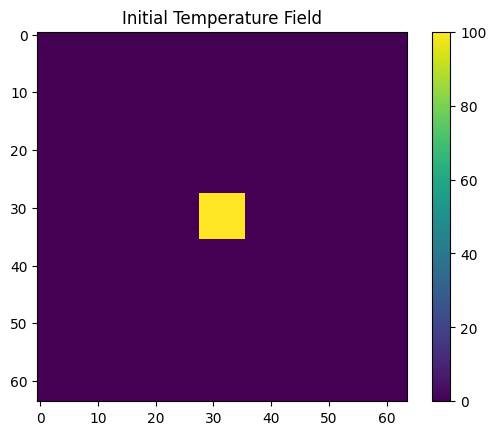

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

nx, ny = 64, 64
alpha = 0.1
dx = dy = 1.0
dt = 0.1

T = np.zeros((nx, ny))

# heat source
T[28:36, 28:36] = 100

plt.imshow(T)
plt.colorbar()
plt.title("Initial Temperature Field")
plt.show()



# Lecture 2 — FDM / FEA Intuition

Industrial FEA tools (ANSYS / COMSOL / Fluent) solve PDEs numerically.

This notebook uses Finite Difference Method (FDM), which is simpler but teaches the same intuition.

---

# Core Idea

Convert PDE into local update rules.

Approximation:

$$
\frac{\partial^2 T}{\partial x^2}
\approx
\frac{
T_{i+1} - 2T_i + T_{i-1}
}{\Delta x^2}
$$

Then repeatedly update the grid.


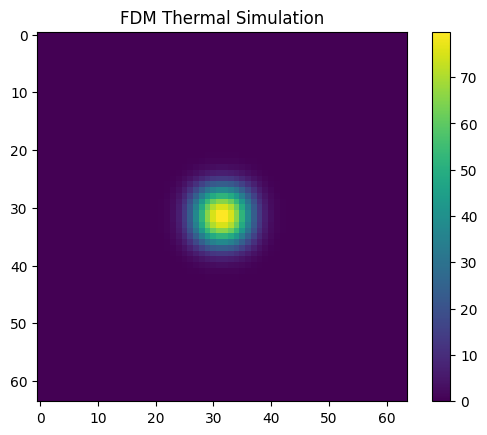

In [ ]:

def simulate_heat(T, steps=3000):

    T = T.copy()

    for _ in range(steps):

        T_new = T.copy()

        T_new[1:-1,1:-1] = T[1:-1,1:-1] + alpha * dt * (
            (T[2:,1:-1] - 2*T[1:-1,1:-1] + T[:-2,1:-1]) +
            (T[1:-1,2:] - 2*T[1:-1,1:-1] + T[1:-1,:-2])
        )

        # boundary conditions
        T_new[:,0] = 0
        T_new[:,-1] = 0
        T_new[0,:] = 0
        T_new[-1,:] = 0

        T = T_new

    return T

final_T = simulate_heat(T)

plt.imshow(final_T)
plt.colorbar()
plt.title("FDM Thermal Simulation")
plt.show()



# Lecture 3 — Why FEA/FDM Is Expensive

Traditional simulation must:

1. Solve PDE iteratively
2. Update every grid point
3. Repeat for every new condition

---

# Industrial Pain Point

Imagine:

- 1000 chip layouts
- 500 cooling conditions
- 200 geometry variations

FEA becomes expensive.

This is where Scientific ML enters.



# Lecture 4 — AI Surrogate Modeling

Instead of solving PDE every time:

```text
Boundary Condition
→ Neural Network
→ Temperature Field
```

This is called:

## Surrogate Modeling

The neural network approximates the simulator.


In [ ]:

dataset_X = []
dataset_Y = []

for sample in range(500):

    T0 = np.zeros((64,64))

    x = np.random.randint(10,54)
    y = np.random.randint(10,54)

    intensity = np.random.uniform(50,150)

    T0[x-3:x+3, y-3:y+3] = intensity

    output = simulate_heat(T0)

    dataset_X.append(T0)
    dataset_Y.append(output)

X = np.array(dataset_X)
Y = np.array(dataset_Y)

print("Dataset shape:", X.shape, Y.shape)


Dataset shape: (500, 64, 64) (500, 64, 64)



# Lecture 5 — CNN Surrogate

CNN works well because thermal maps are spatial fields.

Input:

- heat source map

Output:

- temperature field


In [ ]:

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"

X_tensor = torch.tensor(X).float().unsqueeze(1)
Y_tensor = torch.tensor(Y).float().unsqueeze(1)

loader = DataLoader(
    TensorDataset(X_tensor, Y_tensor),
    batch_size=32,
    shuffle=True
)

class ThermalCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Conv2d(1,16,3,padding=1),
            nn.ReLU(),

            nn.Conv2d(16,32,3,padding=1),
            nn.ReLU(),

            nn.Conv2d(32,32,3,padding=1),
            nn.ReLU(),

            nn.Conv2d(32,1,3,padding=1)
        )

    def forward(self, x):
        return self.net(x)

model = ThermalCNN().to(device)

print(model)


ThermalCNN(
  (net): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
)



# Lecture 6 — Training the Surrogate

This is the first transition:

```text
Simulation
→ Dataset
→ AI Approximation
```


In [ ]:

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

for epoch in range(5):

    total_loss = 0

    for xb, yb in loader:

        xb = xb.to(device)
        yb = yb.to(device)

        pred = model(xb)

        loss = loss_fn(pred, yb)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss: {total_loss:.4f}")


Epoch 1 Loss: 154.2395
Epoch 2 Loss: 16.1737
Epoch 3 Loss: 5.5585
Epoch 4 Loss: 2.9425
Epoch 5 Loss: 1.9351



# Lecture 7 — Comparing FEA/FDM vs AI Surrogate

This is the MOST IMPORTANT lecture.

---

# Traditional FEA / FDM

Advantages:

- Physics-accurate
- Reliable
- General-purpose
- High precision

Disadvantages:

- Slow
- Iterative
- Expensive for repeated runs

---

# PINN / Scientific ML

Advantages:

- Extremely fast inference
- Real-time prediction
- GPU-friendly
- Good for optimization loops
- Good for digital twins

Disadvantages:

- Approximation error
- Needs training data
- Generalization limitations

---

# Key Insight

Scientific ML does NOT replace physics.

It replaces repeated expensive simulation calls.


In [ ]:

import time

sample = X_tensor[:1].to(device)

# FDM timing
start = time.time()

_ = simulate_heat(sample[0,0].cpu().numpy())

fdm_time = time.time() - start

# CNN timing
start = time.time()

with torch.no_grad():
    pred = model(sample)

cnn_time = time.time() - start

print(f"FDM Simulation Time: {fdm_time:.6f} sec")
print(f"CNN Inference Time: {cnn_time:.6f} sec")


FDM Simulation Time: 0.023401 sec
CNN Inference Time: 0.029568 sec



# Interpretation

Typical result:

```text
FDM/FEA:
milliseconds → seconds → minutes

AI Surrogate:
milliseconds
```

This speedup becomes massive in:

- semiconductor thermal optimization
- battery thermal control
- real-time digital twins
- inverse design


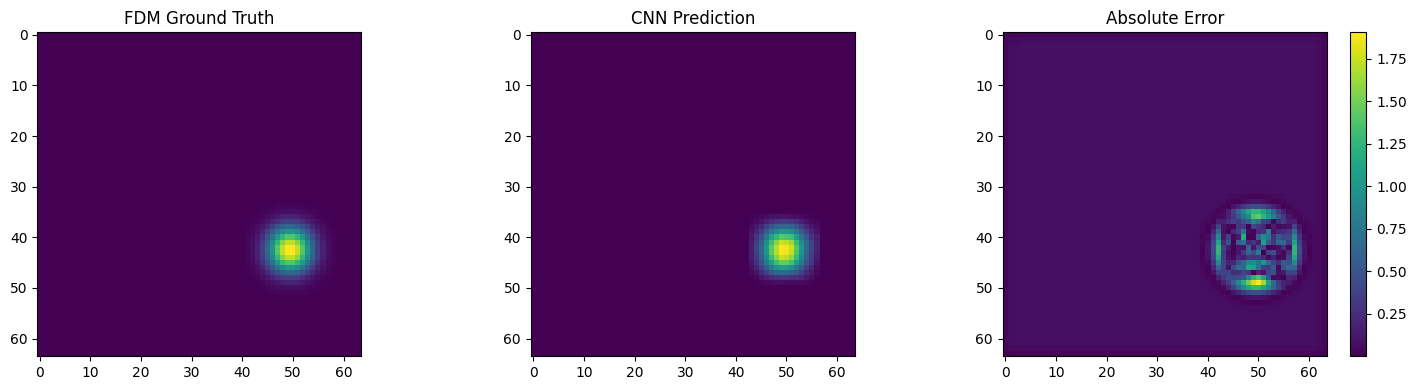

In [ ]:

pred_np = pred[0,0].cpu().numpy()
gt_np = Y_tensor[0,0].numpy()

fig, axes = plt.subplots(1,3, figsize=(15,4))

axes[0].imshow(gt_np)
axes[0].set_title("FDM Ground Truth")

axes[1].imshow(pred_np)
axes[1].set_title("CNN Prediction")

error = np.abs(gt_np - pred_np)

im = axes[2].imshow(error)
axes[2].set_title("Absolute Error")

plt.colorbar(im, ax=axes[2])

plt.tight_layout()
plt.show()



# Lecture 8 — What Is PINN?

PINN = Physics-Informed Neural Network

Instead of ONLY fitting data:

$$
L = L_{data}
$$

PINN adds physics constraints:

$$
L = L_{data} + L_{physics}
$$

---

# Why This Matters

The model is encouraged to obey PDE behavior.

Not just memorize data.


In [ ]:

import torch.nn.functional as F

def laplacian(T):

    return (
        T[:,:,2:,1:-1] +
        T[:,:,:-2,1:-1] +
        T[:,:,1:-1,2:] +
        T[:,:,1:-1,:-2] -
        4 * T[:,:,1:-1,1:-1]
    )

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(3):

    total_loss = 0

    for xb, yb in loader:

        xb = xb.to(device)
        yb = yb.to(device)

        pred = model(xb)

        data_loss = loss_fn(pred, yb)

        lap = laplacian(pred)

        physics_loss = torch.mean(lap**2)

        loss = data_loss + 0.01 * physics_loss

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"PINN-style Epoch {epoch+1} Loss: {total_loss:.4f}")


PINN-style Epoch 1 Loss: 6.0127
PINN-style Epoch 2 Loss: 1.8996
PINN-style Epoch 3 Loss: 1.0788



# Lecture 9 — The Real Industrial Difference

This is the KEY mindset shift.

---

# FEA mindset

```text
Solve PDE every time
```

---

# Scientific ML mindset

```text
Train once
Infer thousands of times
```

---

# Where PINN / SciML Wins

## Real-time systems

Example:

- chip thermal monitoring
- battery safety
- HVAC optimization
- autonomous systems

---

# Where Traditional FEA Wins

## High-precision engineering validation

Example:

- certification
- final design validation
- safety-critical analysis



# Lecture 10 — The Future: Neural Operators

CNN learns:

```text
image → image
```

Neural Operator learns:

```text
function → function
```

This is closer to PDE behavior.

Examples:

- Fourier Neural Operator (FNO)
- DeepONet
- Graph Neural PDE Solvers



# Final Bootcamp Summary

You are NOT becoming:

❌ generic data scientist

You are becoming:

✅ Scientific ML Engineer
✅ Physics AI Engineer
✅ Digital Twin Engineer

---

# Your Core Stack

```text
PDE
→ Simulation
→ Dataset generation
→ Surrogate modeling
→ PINN
→ Neural Operators
→ Industrial deployment
```

---

# Your Portfolio Goal

## Thermal Digital Twin AI

Must include:

- FDM simulation
- AI surrogate
- Physics-informed learning
- Benchmarking
- Visualization
- Industrial framing

---

# Most Important Insight

AI is not replacing physics.

AI is compressing simulation cost.
